In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .appName('AzureDE-InterviewPrep')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '4')
    .getOrCreate()
)
spark

In [8]:
sales = spark.createDataFrame(
    [
        ("c1", 100),
        ("c2", 200),
        ("c3", 300),
        ("c4", 400),
        ("c5", 500),
    ],
    ["customer_id", "amount"]
)

customers = spark.createDataFrame(
    [
        ("c1", "East"),
        ("c2", "West"),
        ("c3", "East"),
        ("c4", "North"),
        ("c5", "South"),
    ],
    ["customer_id", "region"]
)
sales.show()
customers.show()

+-----------+------+
|customer_id|amount|
+-----------+------+
|         c1|   100|
|         c2|   200|
|         c3|   300|
|         c4|   400|
|         c5|   500|
+-----------+------+

+-----------+------+
|customer_id|region|
+-----------+------+
|         c1|  East|
|         c2|  West|
|         c3|  East|
|         c4| North|
|         c5| South|
+-----------+------+



# A1. Join two DataFrames; note Exchange in explain.


In [9]:
joined_df = sales.join(
    customers,
    on="customer_id",
    how="inner"
)

joined_df.show()

+-----------+------+------+
|customer_id|amount|region|
+-----------+------+------+
|         c2|   200|  West|
|         c1|   100|  East|
|         c3|   300|  East|
|         c5|   500| South|
|         c4|   400| North|
+-----------+------+------+



# A2. Broadcast join plan comparison?

In [14]:
from pyspark.sql.functions import broadcast
normal_join = sales.join(
    customers,
    on="customer_id",
    how="inner"
)

normal_join.explain("formatted")
normal_join.show()

== Physical Plan ==
AdaptiveSparkPlan (11)
+- Project (10)
   +- SortMergeJoin Inner (9)
      :- Sort (4)
      :  +- Exchange (3)
      :     +- Filter (2)
      :        +- Scan ExistingRDD (1)
      +- Sort (8)
         +- Exchange (7)
            +- Filter (6)
               +- Scan ExistingRDD (5)


(1) Scan ExistingRDD
Output [2]: [customer_id#52, amount#53L]
Arguments: [customer_id#52, amount#53L], MapPartitionsRDD[72] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Filter
Input [2]: [customer_id#52, amount#53L]
Condition : isnotnull(customer_id#52)

(3) Exchange
Input [2]: [customer_id#52, amount#53L]
Arguments: hashpartitioning(customer_id#52, 4), ENSURE_REQUIREMENTS, [plan_id=517]

(4) Sort
Input [2]: [customer_id#52, amount#53L]
Arguments: [customer_id#52 ASC NULLS FIRST], false, 0

(5) Scan ExistingRDD
Output [2]: [customer_id#54, region#55]
Arguments: [customer_id#54, region#55], MapPartitionsRDD[77] at applySchemaToP

# A3. Partition counts after repartition/coalesce.

| Feature             | `repartition()` | `coalesce()`      |
| ------------------- | --------------- | ----------------- |
| Increase partitions | ✅               | ❌ Generally       |
| Decrease partitions | ✅               | ✅                 |
| Full shuffle        | Usually yes     | Usually no        |
| Expensive           | More expensive  | Cheaper           |
| Data redistribution | Yes             | Limited           |
| Common use          | Balance data    | Reduce partitions |


In [22]:
print("Initial partitions:", sales.rdd.getNumPartitions())
sales_repartitioned = sales.repartition(2)
print("Repartitioned partitions:", sales_repartitioned.rdd.getNumPartitions())

Initial partitions: 2
Repartitioned partitions: 2


In [23]:
sales_repartitioned = sales.repartition(10)

print(
    "After repartition:",
    sales_repartitioned.rdd.getNumPartitions()
)

After repartition: 10


In [24]:
sales_10 = sales.repartition(10)

print(
    "Before coalesce:",
    sales_10.rdd.getNumPartitions()
)

sales_4 = sales_10.coalesce(4)

print(
    "After coalesce:",
    sales_4.rdd.getNumPartitions()
)

Before coalesce: 10
After coalesce: 4


# A4. How do you debug a slow Spark job?

In [27]:
# Step 1
#   Jobs
#   Stages
#   Tasks
#   SQL/DataFrame operations
#   Shuffle Read
#   Shuffle Write
#   Task duration
#   Input size
#   Output size
#   Failed tasks
#   Spill to disk
#   Executor memory
#   Executor CPU

# step -2
#   Stage 4
#   Tasks: 200
#   Average: 10 sec
#   One task: 15 minutes

# Step - 3
# df.explain("formatted")

# I first use Spark UI to identify the slow job, stage, and task.
# Then I inspect the physical plan with explain("formatted"), looking for Exchange, large shuffles, expensive joins, and scans.
# I check partition sizes and data skew, then optimize filters, column selection, joins, partitioning, and file layout.
# I use broadcast when appropriate. Only after identifying the bottleneck would I consider increasing cluster resources.

# A5. One skew example + mitigation.
# What is data skew?

- Data skew occurs when a small number of keys contain a disproportionately large amount of data.

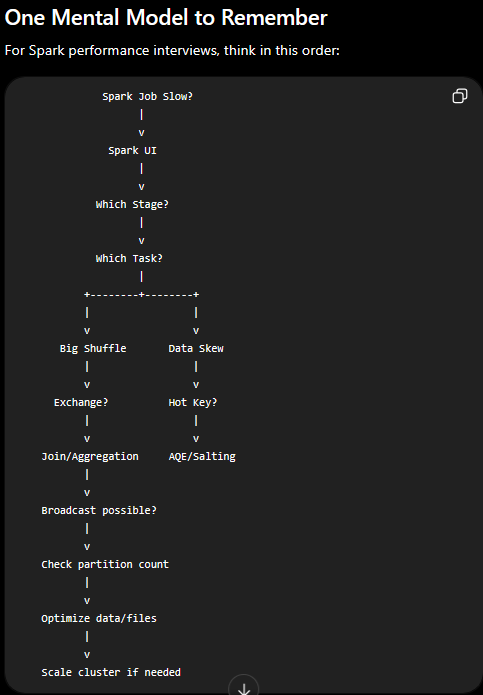

In [31]:
skewed_data = spark.createDataFrame(
    [
        ("c1", 100),
        ("c2", 200),
        ("c3", 300),
        ("UNKNOWN", 1000),
        ("UNKNOWN", 2000),
        ("UNKNOWN", 3000),
    ],
    ["customer_id", "amount"]
)

# How do we identify skew data?
skewed_data.show()

skewed_data.groupBy("customer_id") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+-----------+------+
|customer_id|amount|
+-----------+------+
|         c1|   100|
|         c2|   200|
|         c3|   300|
|    UNKNOWN|  1000|
|    UNKNOWN|  2000|
|    UNKNOWN|  3000|
+-----------+------+

+-----------+-----+
|customer_id|count|
+-----------+-----+
|    UNKNOWN|    3|
|         c3|    1|
|         c2|    1|
|         c1|    1|
+-----------+-----+

